<a href="https://colab.research.google.com/github/lazybird-goofy/learn/blob/main/PINN_Oscillator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

物理参数: m=1.0, μ=0.4, k=4.0
衰减率 δ=0.2000, 固有频率 ω₀=2.0000, 振动频率 ω=1.9900
运动状态: 欠阻尼

▶ 训练普通神经网络 (无物理约束) ...
  Epoch     0 | Loss=0.469130 | Data=0.469130 | Physics=0.000000
  Epoch  2000 | Loss=0.000004 | Data=0.000004 | Physics=0.000000
  Epoch  4000 | Loss=0.000003 | Data=0.000003 | Physics=0.000000

▶ 训练 PINN (含物理损失) ...
  Epoch     0 | Loss=0.544243 | Data=0.543653 | Physics=5.902750
  Epoch  2000 | Loss=0.004978 | Data=0.004354 | Physics=6.238883
  Epoch  4000 | Loss=0.000614 | Data=0.000194 | Physics=4.203118
  Epoch  6000 | Loss=0.000191 | Data=0.000034 | Physics=1.561467
  Epoch  8000 | Loss=0.000080 | Data=0.000017 | Physics=0.631054
  Epoch 10000 | Loss=0.000031 | Data=0.000002 | Physics=0.288859
  Epoch 12000 | Loss=0.000026 | Data=0.000001 | Physics=0.248785
  Epoch 14000 | Loss=0.000024 | Data=0.000001 | Physics=0.229392
  Epoch 16000 | Loss=0.000022 | Data=0.000000 | Physics=0.213747
  Epoch 18000 | Loss=0.000020 | Data=0.000000 | Physics=0.199220


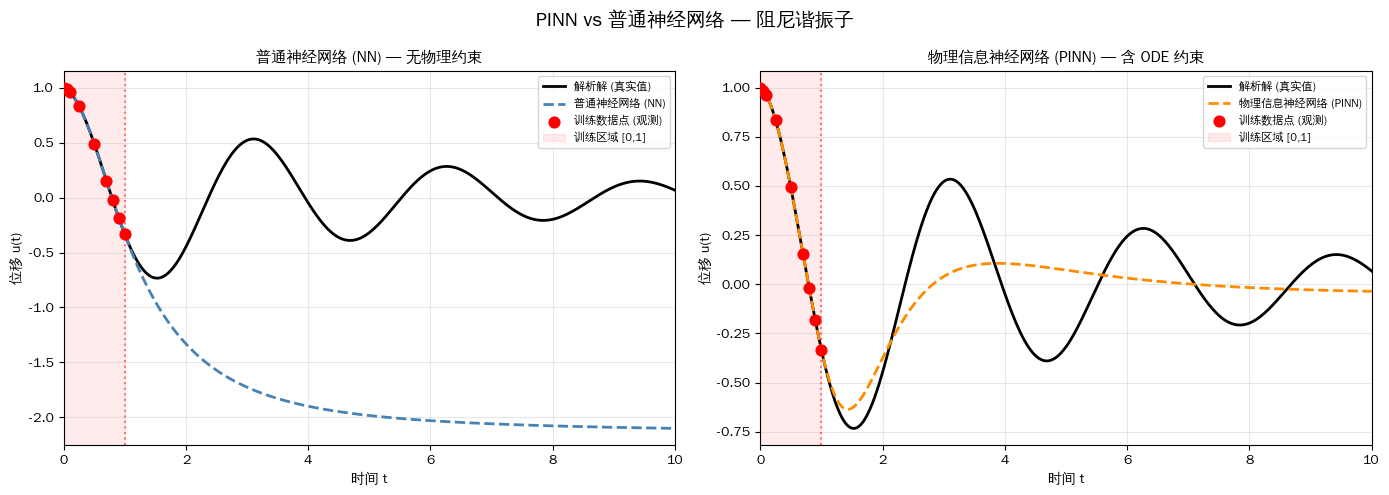

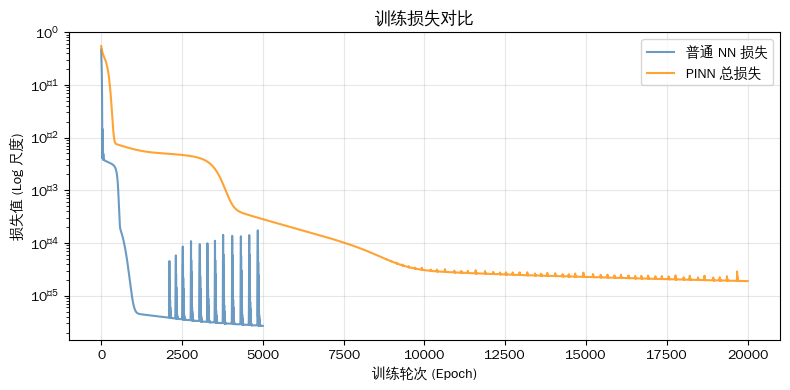


误差对比 (MSE = 均方误差)
------------------------------------------------------------
区域                   普通 NN                PINN                
------------------------------------------------------------
训练区域 [0,1]           0.000003             0.000000            
外推区域 [1,10]          3.602900             0.055937            
全域 [0,10]            3.242611             0.050344            

结论: PINN 在外推区域（无观测数据）的误差远小于普通 NN。
      物理约束使模型能够泛化到训练数据范围之外。

▶ 逆问题: 从数据反推摩擦系数 μ
  初始猜测 μ = 0.1000, 真实值 μ = 0.4000
  Epoch     0 | Loss=0.320526 | μ_学习值=0.0990
  Epoch  2000 | Loss=0.000156 | μ_学习值=0.4401
  Epoch  4000 | Loss=0.000098 | μ_学习值=0.4169
  Epoch  6000 | Loss=0.000021 | μ_学习值=0.4082
  Epoch  8000 | Loss=0.000008 | μ_学习值=0.4043

反推结果: μ_预测 = 0.4022, 真实 μ = 0.4
误差: 0.002238

✅ 完成! 图像已保存至输出目录。


In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import os

# Configure matplotlib to display Chinese characters
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'Arial Unicode MS'] # Use the installed font first
plt.rcParams['axes.unicode_minus'] = False  # Display minus sign normally

# ─────────────────────────────────────────────
# 0. 随机种子（可复现）
# ─────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ─────────────────────────────────────────────
# 1. 物理参数
# ─────────────────────────────────────────────
m  = 1.0   # 质量 mass
mu = 0.4   # 摩擦系数 friction coefficient
k  = 4.0   # 弹簧常数 spring constant

# 阻尼参数（辅助计算解析解）
delta = mu / (2 * m)              # 衰减率
omega0 = np.sqrt(k / m)           # 固有频率
omega = np.sqrt(omega0**2 - delta**2)  # 有阻尼振动频率

print(f"物理参数: m={m}, μ={mu}, k={k}")
print(f"衰减率 δ={delta:.4f}, 固有频率 ω₀={omega0:.4f}, 振动频率 ω={omega:.4f}")
print(f"运动状态: {'欠阻尼' if delta < omega0 else '过阻尼/临界阻尼'}")


# ─────────────────────────────────────────────
# 2. 解析解（用于对比验证）
# ─────────────────────────────────────────────
def analytic_solution(t):
    """
    阻尼谐振子解析解
    u(t) = exp(-δt) * cos(ωt)  (满足初始条件 u(0)=1, u'(0)=0)
    """
    return np.exp(-delta * t) * np.cos(omega * t)


# ─────────────────────────────────────────────
# 3. 训练数据点（稀疏观测点，模拟实验测量）
# ─────────────────────────────────────────────
# 稀疏采样 9 个训练点，范围 t ∈ [0, 1]
t_train_np = np.array([0.0, 0.05, 0.1, 0.25, 0.5, 0.7, 0.8, 0.9, 1.0])
u_train_np = analytic_solution(t_train_np)

# 转为 PyTorch 张量
t_train = torch.tensor(t_train_np, dtype=torch.float32).reshape(-1, 1)
u_train = torch.tensor(u_train_np, dtype=torch.float32).reshape(-1, 1)

# 物理约束点（配点法，collocations），均匀分布于整个求解域 t ∈ [0, 10]
N_physics = 300
t_physics_np = np.linspace(0, 10, N_physics)
t_physics = torch.tensor(t_physics_np, dtype=torch.float32).reshape(-1, 1)
t_physics.requires_grad_(True)   # 需要对 t 求导

# 完整评估区间
t_eval_np = np.linspace(0, 10, 500)
t_eval = torch.tensor(t_eval_np, dtype=torch.float32).reshape(-1, 1)


# ─────────────────────────────────────────────
# 4. 神经网络定义
# ─────────────────────────────────────────────
class FCN(nn.Module):
    """
    全连接前馈神经网络 (Fully Connected Network)
    架构: 1 → 32 → 32 → 32 → 1
    激活函数: Tanh（对 PINN 比 ReLU 更平滑，导数更稳定）
    """
    def __init__(self, layers):
        super(FCN, self).__init__()
        self.net = nn.Sequential()
        for i in range(len(layers) - 1):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:
                self.net.add_module(f'tanh_{i}', nn.Tanh())
        # Xavier 初始化，有利于梯度传播
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)


# 实例化两个网络（普通 NN vs PINN，便于对比）
layers = [1, 32, 32, 32, 1]
nn_model   = FCN(layers)    # 普通神经网络（无物理约束）
pinn_model = FCN(layers)    # 物理信息神经网络


# ─────────────────────────────────────────────
# 5. 物理残差计算函数
# ─────────────────────────────────────────────
def physics_residual(model, t):
    """
    计算 ODE 残差: m*u'' + μ*u' + k*u
    使用 PyTorch 自动微分（autograd）
    """
    u = model(t)

    # 一阶导数 du/dt
    u_t = torch.autograd.grad(
        u, t,
        grad_outputs=torch.ones_like(u),
        create_graph=True,   # 保留计算图以便计算高阶导数
        retain_graph=True
    )[0]

    # 二阶导数 d²u/dt²
    u_tt = torch.autograd.grad(
        u_t, t,
        grad_outputs=torch.ones_like(u_t),
        create_graph=True,
        retain_graph=True
    )[0]

    # ODE 残差（应为 0 时表示满足物理方程）
    residual = m * u_tt + mu * u_t + k * u
    return residual


# ─────────────────────────────────────────────
# 6. 训练函数
# ─────────────────────────────────────────────
def train_model(model, use_physics=True, n_epochs=20000, lr=1e-4, physics_weight=1e-4):
    """
    训练 NN 或 PINN

    参数:
        model:          要训练的神经网络
        use_physics:    True = PINN (加入物理损失), False = 普通 NN
        n_epochs:       训练轮次
        lr:             学习率
        physics_weight: 物理损失权重（用于平衡两项损失）

    损失:
        PINN: L = L_data + λ * L_physics
        NN:   L = L_data
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        # ── 数据损失（拟合观测点）──
        u_pred = model(t_train)
        loss_data = torch.mean((u_pred - u_train) ** 2)

        # ── 物理损失（满足 ODE 约束）──
        if use_physics:
            residual = physics_residual(model, t_physics)
            loss_phys = torch.mean(residual ** 2)
            loss = loss_data + physics_weight * loss_phys
        else:
            loss_phys = torch.tensor(0.0)
            loss = loss_data

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if epoch % 2000 == 0:
            print(f"  Epoch {epoch:5d} | Loss={loss.item():.6f} | "
                  f"Data={loss_data.item():.6f} | "
                  f"Physics={loss_phys.item():.6f}")

    return loss_history


# ─────────────────────────────────────────────
# 7. 训练普通 NN（无物理约束）
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("▶ 训练普通神经网络 (无物理约束) ...")
print("="*50)
# 普通 NN 学习更快，用较少 epoch 即可收敛
nn_loss = train_model(nn_model, use_physics=False, n_epochs=5000, lr=1e-3)


# ─────────────────────────────────────────────
# 8. 训练 PINN（含物理约束）
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("▶ 训练 PINN (含物理损失) ...")
print("="*50)
pinn_loss = train_model(pinn_model, use_physics=True, n_epochs=20000, lr=1e-4,
                        physics_weight=1e-4)


# ─────────────────────────────────────────────
# 9. 预测 & 可视化
# ─────────────────────────────────────────────
pinn_model.eval()
nn_model.eval()

with torch.no_grad():
    u_nn_pred   = nn_model(t_eval).numpy().flatten()
    u_pinn_pred = pinn_model(t_eval).numpy().flatten()

u_true = analytic_solution(t_eval_np)

# Create the output directory if it doesn't exist
os.makedirs('/mnt/user-data/outputs/', exist_ok=True)

# ── 图1：预测对比 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PINN vs 普通神经网络 — 阻尼谐振子", fontsize=14, fontweight='bold')

for ax, title, pred, color in [
    (axes[0], "普通神经网络 (NN) — 无物理约束", u_nn_pred, 'steelblue'),
    (axes[1], "物理信息神经网络 (PINN) — 含 ODE 约束", u_pinn_pred, 'darkorange'),
]:
    ax.plot(t_eval_np, u_true, 'k-', linewidth=2, label='解析解 (真实值)')
    ax.plot(t_eval_np, pred, '--', color=color, linewidth=2, label=title.split('—')[0].strip())
    ax.scatter(t_train_np, u_train_np.numpy() if hasattr(u_train_np, 'numpy')
               else u_train_np, color='red', zorder=5, s=60, label='训练数据点 (观测)')
    # 标记训练区域
    ax.axvspan(0, 1, alpha=0.08, color='red', label='训练区域 [0,1]')
    ax.axvline(x=1, color='red', linestyle=':', alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('时间 t', fontsize=10)
    ax.set_ylabel('位移 u(t)', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 10)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/pinn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 图2：损失曲线 ──
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.semilogy(nn_loss, label='普通 NN 损失', color='steelblue', alpha=0.8)
ax2.semilogy(pinn_loss, label='PINN 总损失', color='darkorange', alpha=0.8)
ax2.set_xlabel('训练轮次 (Epoch)')
ax2.set_ylabel('损失值 (Log 尺度)')
ax2.set_title('训练损失对比')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/pinn_loss.png', dpi=150, bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────
# 10. 量化误差评估
# ─────────────────────────────────────────────
# 分段评估：训练区域 [0,1] vs 外推区域 [1,10]
mask_train = t_eval_np <= 1.0
mask_extrap = t_eval_np > 1.0

def mse(a, b): return np.mean((a - b)**2)

print("\n" + "="*60)
print("误差对比 (MSE = 均方误差)")
print("-"*60)
print(f"{'区域':<20} {'普通 NN':<20} {'PINN':<20}")
print("-"*60)
print(f"{'训练区域 [0,1]':<20} "
      f"{mse(u_nn_pred[mask_train], u_true[mask_train]):<20.6f} "
      f"{mse(u_pinn_pred[mask_train], u_true[mask_train]):<20.6f}")
print(f"{'外推区域 [1,10]':<20} "
      f"{mse(u_nn_pred[mask_extrap], u_true[mask_extrap]):<20.6f} "
      f"{mse(u_pinn_pred[mask_extrap], u_true[mask_extrap]):<20.6f}")
print(f"{'全域 [0,10]':<20} "
      f"{mse(u_nn_pred, u_true):<20.6f} "
      f"{mse(u_pinn_pred, u_true):<20.6f}")
print("="*60)
print("\n结论: PINN 在外推区域（无观测数据）的误差远小于普通 NN。")
print("      物理约束使模型能够泛化到训练数据范围之外。")


# ─────────────────────────────────────────────
# 11. 附加：逆问题演示 (Inverse Problem)
#     已知观测数据，反推物理参数 μ（摩擦系数）
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("▶ 逆问题: 从数据反推摩擦系数 μ")
print("="*50)

# 更多训练数据（逆问题需要更多信息）
t_inv_np = np.linspace(0, 5, 50)
u_inv_np = analytic_solution(t_inv_np)
t_inv = torch.tensor(t_inv_np, dtype=torch.float32).reshape(-1, 1)
u_inv = torch.tensor(u_inv_np, dtype=torch.float32).reshape(-1, 1)

# 物理约束点
t_phys_inv = torch.tensor(np.linspace(0, 5, 200), dtype=torch.float32).reshape(-1, 1)
t_phys_inv.requires_grad_(True)

# 待学习的物理参数（初始猜测）
mu_learnable = nn.Parameter(torch.tensor([0.1]))  # 真实值为 0.4

# 新的 PINN（用于逆问题）
inv_model = FCN([1, 32, 32, 32, 1])
optimizer_inv = torch.optim.Adam(
    list(inv_model.parameters()) + [mu_learnable],
    lr=1e-3
)

inv_loss_history = []
print(f"  初始猜测 μ = {mu_learnable.item():.4f}, 真实值 μ = {mu:.4f}")

for epoch in range(10000):
    optimizer_inv.zero_grad()

    # 数据损失
    u_pred_inv = inv_model(t_inv)
    loss_data = torch.mean((u_pred_inv - u_inv) ** 2)

    # 物理损失（使用可学习的 μ）
    u_phys = inv_model(t_phys_inv)
    u_t = torch.autograd.grad(u_phys, t_phys_inv,
                               grad_outputs=torch.ones_like(u_phys),
                               create_graph=True)[0]
    u_tt = torch.autograd.grad(u_t, t_phys_inv,
                                grad_outputs=torch.ones_like(u_t),
                                create_graph=True)[0]
    residual = m * u_tt + mu_learnable * u_t + k * u_phys
    loss_phys = torch.mean(residual ** 2)

    loss_inv = loss_data + 1e-3 * loss_phys
    loss_inv.backward()
    optimizer_inv.step()
    inv_loss_history.append(loss_inv.item())

    if epoch % 2000 == 0:
        print(f"  Epoch {epoch:5d} | Loss={loss_inv.item():.6f} | "
              f"μ_学习值={mu_learnable.item():.4f}")

print(f"\n反推结果: μ_预测 = {mu_learnable.item():.4f}, 真实 μ = {mu}")
print(f"误差: {abs(mu_learnable.item() - mu):.6f}")
print("\n✅ 完成! 图像已保存至输出目录。")

Epoch 1000  | Total: 0.14001 | BC1: 0.00000 | Phys: 139.75488
Epoch 2000  | Total: 0.10268 | BC1: 0.00000 | Phys: 102.53104
Epoch 3000  | Total: 0.03301 | BC1: 0.00000 | Phys: 32.98875
Epoch 4000  | Total: 0.02134 | BC1: 0.00000 | Phys: 21.32429
Epoch 5000  | Total: 0.01595 | BC1: 0.00000 | Phys: 15.92746
Epoch 6000  | Total: 0.00543 | BC1: 0.00001 | Phys: 4.56464
Epoch 7000  | Total: 0.00109 | BC1: 0.00000 | Phys: 1.09056
Epoch 8000  | Total: 0.00072 | BC1: 0.00000 | Phys: 0.72014


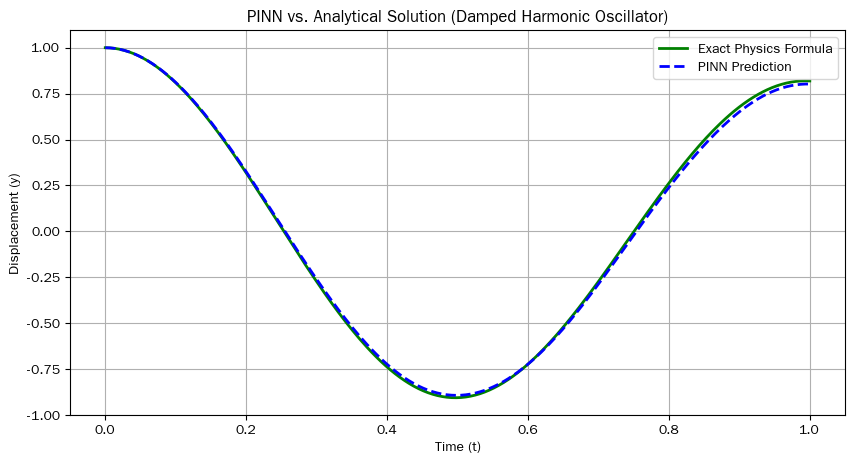

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. 网络结构定义 (同前)
class MLP(nn.Module):
    def __init__(self, hidden_layers=4, hidden_width=32):
        super().__init__()
        layers = [nn.Linear(1, hidden_width), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_width, hidden_width))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_width, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, t):
        return self.network(t)

# 2. 物理方程残差
def get_physics_residual(model, t, params):
    m, mu, k = params
    y = model(t)
    dydt = torch.autograd.grad(y, t, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    d2ydt2 = torch.autograd.grad(dydt, t, grad_outputs=torch.ones_like(dydt), create_graph=True)[0]
    residual = m * d2ydt2 + mu * dydt + k * y
    return residual

# 3. 边界条件残差
def get_bc_residuals(model, t_bc):
    y = model(t_bc)
    dydt = torch.autograd.grad(y, t_bc, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    res_bc1 = y - 1.0
    res_bc2 = dydt - 0.0
    return res_bc1, res_bc2

# ================= 新增：真实的物理学解析解 =================
def exact_solution(t_np, m=1.0, mu=0.4, k=40.0):
    """
    求解 m*y'' + mu*y' + k*y = 0, y(0)=1, y'(0)=0 的数学解析解
    """
    gamma = mu / (2 * m)
    omega_0 = np.sqrt(k / m)
    omega_d = np.sqrt(omega_0**2 - gamma**2) # 阻尼振荡频率

    A = 1.0
    B = gamma / omega_d

    # 物理公式：y(t) = e^(-gamma*t) * (A*cos(w_d*t) + B*sin(w_d*t))
    y_exact = np.exp(-gamma * t_np) * (A * np.cos(omega_d * t_np) + B * np.sin(omega_d * t_np))
    return y_exact
# ==========================================================

# 4. 优化后的训练流程
def train():
    params = (1.0, 0.4, 40.0)
    model = MLP(hidden_layers=4, hidden_width=32)
    # 稍微降低学习率，增加稳定性
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    t_colloc = torch.linspace(0, 1, 100).reshape(-1, 1) # 增加物理配点到100个
    t_colloc.requires_grad = True

    t_bc = torch.zeros((1, 1))
    t_bc.requires_grad = True

    epochs = 8000 # 振荡方程需要更多的迭代次数

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        res_bc1, res_bc2 = get_bc_residuals(model, t_bc)
        loss_bc1 = torch.mean(res_bc1 ** 2)
        loss_bc2 = torch.mean(res_bc2 ** 2)

        res_phys = get_physics_residual(model, t_colloc, params)
        loss_phys = torch.mean(res_phys ** 2)

        # 🔥 核心修正：权重平衡 (Weight Balancing) 🔥
        # 强迫网络死死咬住初始点 y(0)=1，并削弱物理残差初期的统治力
        lambda_bc1 = 100.0   # 极大地惩罚起点不在 1 的行为
        lambda_bc2 = 10.0    # 惩罚初始速度不是 0 的行为
        lambda_phys = 1e-3   # 降低物理方程权重的绝对值

        total_loss = lambda_bc1 * loss_bc1 + lambda_bc2 * loss_bc2 + lambda_phys * loss_phys

        total_loss.backward()
        optimizer.step()

        if (epoch+1) % 1000 == 0:
            print(f"Epoch {epoch+1:<5} | Total: {total_loss.item():.5f} | BC1: {loss_bc1.item():.5f} | Phys: {loss_phys.item():.5f}")

    return model

# 5. 测试与可视化 (对比预测与真实物理公式)
def test(model):
    model.eval()
    t_test_tensor = torch.linspace(0, 1, 300).reshape(-1, 1)
    t_test_np = t_test_tensor.numpy().flatten()

    with torch.no_grad():
        y_pred = model(t_test_tensor).detach().numpy().flatten()

    # 计算精确的物理结果
    y_exact = exact_solution(t_test_np)

    plt.figure(figsize=(10, 5))
    plt.plot(t_test_np, y_exact, 'g-', label="Exact Physics Formula", linewidth=2)
    plt.plot(t_test_np, y_pred, 'b--', label="PINN Prediction", linewidth=2)
    plt.title("PINN vs. Analytical Solution (Damped Harmonic Oscillator)")
    plt.xlabel("Time (t)")
    plt.ylabel("Displacement (y)")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    trained_model = train()
    test(trained_model)

In [3]:
import matplotlib.font_manager as fm

# Install a Chinese font (e.g., wqy-zenhei)
!apt-get update
!apt-get install -y fonts-wqy-zenhei

# Find the font path
font_path = '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'

# Add the font to matplotlib's font manager
fm.fontManager.addfont(font_path)

# Set matplotlib's default font to the newly installed font
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'Arial Unicode MS'] # Use the installed font first
plt.rcParams['axes.unicode_minus'] = False # Ensure minus signs are displayed correctly

print(f"Installed font '{fm.FontProperties(fname=font_path).get_name()}' and configured Matplotlib.")


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [93.4 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.2 MB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,294 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,004 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packag


▶ 训练普通神经网络 (无物理约束) ...
  Epoch     0 | Loss=11.676522 | Data=0.465294 | Physics=0.000000
  Epoch  2000 | Loss=0.000119 | Data=0.000074 | Physics=0.000000
  Epoch  4000 | Loss=0.000046 | Data=0.000046 | Physics=0.000000

▶ 训练 PINN (含物理损失) ...
  Epoch     0 | Loss=19.060390 | Data=0.597051 | Physics=5.902750
  Epoch  2000 | Loss=0.097762 | Data=0.001798 | Physics=0.094968
  Epoch  4000 | Loss=0.024520 | Data=0.000104 | Physics=0.024360
  Epoch  6000 | Loss=0.020841 | Data=0.000075 | Physics=0.020726
  Epoch  8000 | Loss=0.014317 | Data=0.000026 | Physics=0.014070
  Epoch 10000 | Loss=0.011417 | Data=0.000026 | Physics=0.011378
  Epoch 12000 | Loss=0.010274 | Data=0.000022 | Physics=0.010241
  Epoch 14000 | Loss=0.007838 | Data=0.000014 | Physics=0.007818
  Epoch 16000 | Loss=0.001705 | Data=0.000002 | Physics=0.001702
  Epoch 18000 | Loss=0.000136 | Data=0.000000 | Physics=0.000134


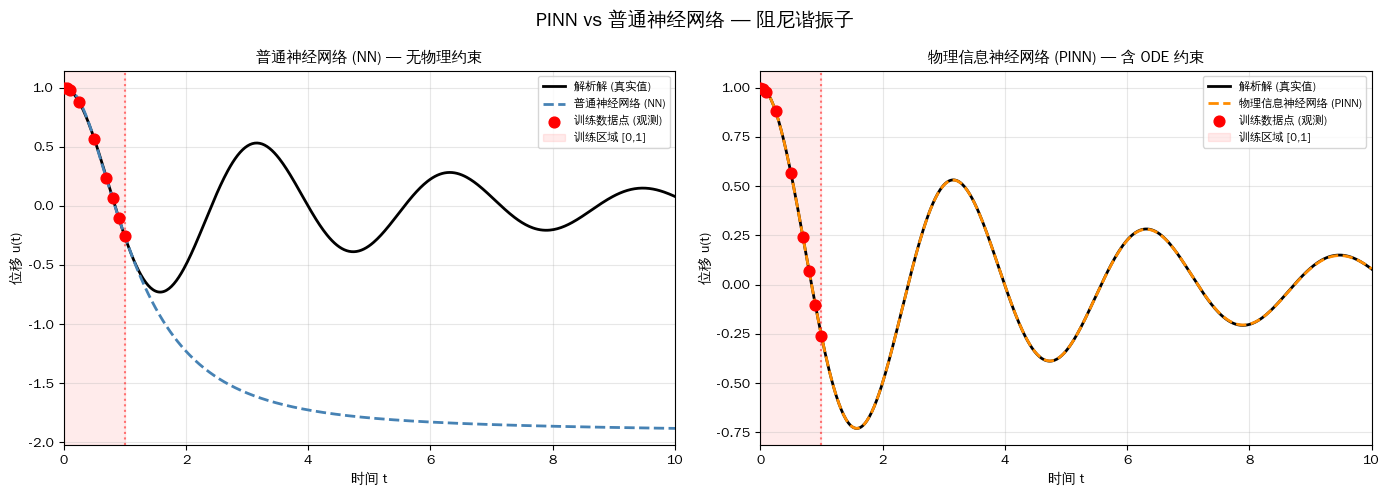


▶ 逆问题: 从数据反推摩擦系数 μ
  初始猜测 μ = 0.1000, 真实值 μ = 0.4000
  Epoch     0 | Loss=1.420097 | μ_学习值=0.0990
  Epoch  2000 | Loss=0.005639 | μ_学习值=0.5734
  Epoch  4000 | Loss=0.000325 | μ_学习值=0.4137
  Epoch  6000 | Loss=0.000133 | μ_学习值=0.4014
  Epoch  8000 | Loss=0.000082 | μ_学习值=0.3997

反推结果: μ_预测 = 0.3995, 真实 μ = 0.4
误差: 0.000537


In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os

# Configure matplotlib to display Chinese characters
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ─────────────────────────────────────────────
# 0. 随机种子（可复现）
# ─────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ─────────────────────────────────────────────
# 1. 物理参数
# ─────────────────────────────────────────────
m  = 1.0   # 质量 mass
mu = 0.4   # 摩擦系数 friction coefficient
k  = 4.0   # 弹簧常数 spring constant

delta = mu / (2 * m)              # 衰减率
omega0 = np.sqrt(k / m)           # 固有频率
omega = np.sqrt(omega0**2 - delta**2)  # 有阻尼振动频率

# ─────────────────────────────────────────────
# 2. 解析解（修正：满足 u(0)=1, u'(0)=0）
# ─────────────────────────────────────────────
def analytic_solution(t):
    """
    修正后的阻尼谐振子解析解
    确保初始速度项被正确抵消，满足 u'(0)=0
    """
    return np.exp(-delta * t) * (np.cos(omega * t) + (delta / omega) * np.sin(omega * t))

# ─────────────────────────────────────────────
# 3. 训练数据点
# ─────────────────────────────────────────────
t_train_np = np.array([0.0, 0.05, 0.1, 0.25, 0.5, 0.7, 0.8, 0.9, 1.0])
u_train_np = analytic_solution(t_train_np)

t_train = torch.tensor(t_train_np, dtype=torch.float32).reshape(-1, 1)
u_train = torch.tensor(u_train_np, dtype=torch.float32).reshape(-1, 1)

N_physics = 300
t_physics_np = np.linspace(0, 10, N_physics)
t_physics = torch.tensor(t_physics_np, dtype=torch.float32).reshape(-1, 1)
t_physics.requires_grad_(True)

t_eval_np = np.linspace(0, 10, 500)
t_eval = torch.tensor(t_eval_np, dtype=torch.float32).reshape(-1, 1)

# ─────────────────────────────────────────────
# 4. 神经网络定义
# ─────────────────────────────────────────────
class FCN(nn.Module):
    def __init__(self, layers):
        super(FCN, self).__init__()
        self.net = nn.Sequential()
        for i in range(len(layers) - 1):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:
                self.net.add_module(f'tanh_{i}', nn.Tanh())
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)

layers = [1, 32, 32, 32, 1]
nn_model   = FCN(layers)
pinn_model = FCN(layers)

# ─────────────────────────────────────────────
# 5. 物理残差计算函数
# ─────────────────────────────────────────────
def physics_residual(model, t):
    u = model(t)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]
    u_tt = torch.autograd.grad(u_t, t, grad_outputs=torch.ones_like(u_t), create_graph=True, retain_graph=True)[0]
    residual = m * u_tt + mu * u_t + k * u
    return residual

# ─────────────────────────────────────────────
# 6. 训练函数（引入学习率衰减 & 显式边界条件）
# ─────────────────────────────────────────────
def train_model(model, use_physics=True, n_epochs=20000, lr=1e-3, physics_weight=1.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # 加入学习率调度器，每 5000 轮学习率减半
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)
    loss_history = []

    # 用于计算初始条件 u(0)=1, u'(0)=0
    t_0 = torch.tensor([[0.0]], dtype=torch.float32, requires_grad=True)

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        # ── 数据损失 ──
        u_pred = model(t_train)
        loss_data = torch.mean((u_pred - u_train) ** 2)

        # ── 初始条件损失 (IC Loss) ──
        u_0 = model(t_0)
        u_0_t = torch.autograd.grad(u_0, t_0, grad_outputs=torch.ones_like(u_0), create_graph=True)[0]
        loss_ic = (u_0 - 1.0)**2 + (u_0_t - 0.0)**2
        loss_ic = torch.mean(loss_ic)

        # ── 物理损失 ──
        if use_physics:
            residual = physics_residual(model, t_physics)
            loss_phys = torch.mean(residual ** 2)
            # 总损失：数据 + 强约束初始条件 + 强约束物理定律
            loss = loss_data + 10.0 * loss_ic + physics_weight * loss_phys
        else:
            loss_phys = torch.tensor(0.0)
            loss = loss_data + 10.0 * loss_ic  # 普通NN也给予初始点约束以公平对比

        loss.backward()
        optimizer.step()
        scheduler.step()

        loss_history.append(loss.item())

        if epoch % 2000 == 0:
            print(f"  Epoch {epoch:5d} | Loss={loss.item():.6f} | "
                  f"Data={loss_data.item():.6f} | "
                  f"Physics={loss_phys.item():.6f}")

    return loss_history

# ─────────────────────────────────────────────
# 7. 训练普通 NN
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("▶ 训练普通神经网络 (无物理约束) ...")
print("="*50)
nn_loss = train_model(nn_model, use_physics=False, n_epochs=5000, lr=1e-3)

# ─────────────────────────────────────────────
# 8. 训练 PINN（提升 physics_weight 为 1.0）
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("▶ 训练 PINN (含物理损失) ...")
print("="*50)
pinn_loss = train_model(pinn_model, use_physics=True, n_epochs=20000, lr=1e-3, physics_weight=1.0)

# ─────────────────────────────────────────────
# 9. 预测 & 可视化
# ─────────────────────────────────────────────
pinn_model.eval()
nn_model.eval()

with torch.no_grad():
    u_nn_pred   = nn_model(t_eval).numpy().flatten()
    u_pinn_pred = pinn_model(t_eval).numpy().flatten()

u_true = analytic_solution(t_eval_np)

os.makedirs('/mnt/user-data/outputs/', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PINN vs 普通神经网络 — 阻尼谐振子", fontsize=14, fontweight='bold')

for ax, title, pred, color in [
    (axes[0], "普通神经网络 (NN) — 无物理约束", u_nn_pred, 'steelblue'),
    (axes[1], "物理信息神经网络 (PINN) — 含 ODE 约束", u_pinn_pred, 'darkorange'),
]:
    ax.plot(t_eval_np, u_true, 'k-', linewidth=2, label='解析解 (真实值)')
    ax.plot(t_eval_np, pred, '--', color=color, linewidth=2, label=title.split('—')[0].strip())
    ax.scatter(t_train_np, u_train_np.numpy() if hasattr(u_train_np, 'numpy') else u_train_np, color='red', zorder=5, s=60, label='训练数据点 (观测)')
    ax.axvspan(0, 1, alpha=0.08, color='red', label='训练区域 [0,1]')
    ax.axvline(x=1, color='red', linestyle=':', alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('时间 t', fontsize=10)
    ax.set_ylabel('位移 u(t)', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 10)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/pinn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 11. 附加：逆问题演示 (同样调高物理权重)
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("▶ 逆问题: 从数据反推摩擦系数 μ")
print("="*50)

t_inv_np = np.linspace(0, 5, 50)
u_inv_np = analytic_solution(t_inv_np)
t_inv = torch.tensor(t_inv_np, dtype=torch.float32).reshape(-1, 1)
u_inv = torch.tensor(u_inv_np, dtype=torch.float32).reshape(-1, 1)

t_phys_inv = torch.tensor(np.linspace(0, 5, 200), dtype=torch.float32).reshape(-1, 1)
t_phys_inv.requires_grad_(True)

mu_learnable = nn.Parameter(torch.tensor([0.1]))

inv_model = FCN([1, 32, 32, 32, 1])
optimizer_inv = torch.optim.Adam(list(inv_model.parameters()) + [mu_learnable], lr=1e-3)
scheduler_inv = torch.optim.lr_scheduler.StepLR(optimizer_inv, step_size=3000, gamma=0.5)

inv_loss_history = []
print(f"  初始猜测 μ = {mu_learnable.item():.4f}, 真实值 μ = {mu:.4f}")

for epoch in range(10000):
    optimizer_inv.zero_grad()

    u_pred_inv = inv_model(t_inv)
    loss_data = torch.mean((u_pred_inv - u_inv) ** 2)

    u_phys = inv_model(t_phys_inv)
    u_t = torch.autograd.grad(u_phys, t_phys_inv, grad_outputs=torch.ones_like(u_phys), create_graph=True)[0]
    u_tt = torch.autograd.grad(u_t, t_phys_inv, grad_outputs=torch.ones_like(u_t), create_graph=True)[0]

    residual = m * u_tt + mu_learnable * u_t + k * u_phys
    loss_phys = torch.mean(residual ** 2)

    # 提升逆问题中的物理权重
    loss_inv = loss_data + 1.0 * loss_phys
    loss_inv.backward()

    optimizer_inv.step()
    scheduler_inv.step()

    inv_loss_history.append(loss_inv.item())

    if epoch % 2000 == 0:
        print(f"  Epoch {epoch:5d} | Loss={loss_inv.item():.6f} | μ_学习值={mu_learnable.item():.4f}")

print(f"\n反推结果: μ_预测 = {mu_learnable.item():.4f}, 真实 μ = {mu}")
print(f"误差: {abs(mu_learnable.item() - mu):.6f}")